In [2]:
import h5py

file = h5py.File("24thJune.h5", "r")
print(list(file.keys()))  # shows top-level groups


['Metadata', 'Soil_Moisture_Retrieval_Data_AM', 'Soil_Moisture_Retrieval_Data_PM', 'Soil_Moisture_Retrieval_Data_Polar_AM', 'Soil_Moisture_Retrieval_Data_Polar_PM']


In [35]:
# Metadata - Information about the dataset (version, processing, timestamps).
# Soil_Moisture_Retrieval_Data_AM → Morning satellite pass data.
# Soil_Moisture_Retrieval_Data_PM → Afternoon satellite pass data.
# Soil_Moisture_Retrieval_Data_Polar_AM → Polar orbit morning data.
# Soil_Moisture_Retrieval_Data_Polar_PM → Polar orbit afternoon data.

In [4]:
# Picked one group to explore (Soil_Moisture_Retrieval_Data_AM).

group = file["Soil_Moisture_Retrieval_Data_AM"]
print(list(group.keys()))  # shows datasets inside this group


['EASE_column_index', 'EASE_row_index', 'albedo', 'albedo_dca', 'albedo_scah', 'albedo_scav', 'boresight_incidence', 'bulk_density', 'clay_fraction', 'freeze_thaw_fraction', 'grid_surface_status', 'latitude', 'latitude_centroid', 'longitude', 'longitude_centroid', 'radar_water_body_fraction', 'retrieval_qual_flag', 'retrieval_qual_flag_dca', 'retrieval_qual_flag_scah', 'retrieval_qual_flag_scav', 'roughness_coefficient', 'roughness_coefficient_dca', 'roughness_coefficient_scah', 'roughness_coefficient_scav', 'soil_moisture', 'soil_moisture_dca', 'soil_moisture_error', 'soil_moisture_scah', 'soil_moisture_scav', 'static_water_body_fraction', 'surface_flag', 'surface_temperature', 'surface_water_fraction_mb_h', 'surface_water_fraction_mb_v', 'tb_3_corrected', 'tb_4_corrected', 'tb_h_corrected', 'tb_h_uncorrected', 'tb_qual_flag_3', 'tb_qual_flag_4', 'tb_qual_flag_h', 'tb_qual_flag_v', 'tb_time_seconds', 'tb_time_utc', 'tb_v_corrected', 'tb_v_uncorrected', 'vegetation_opacity', 'vegetatio

In [5]:
# dataset shapes and values

soil_moisture = group["soil_moisture"][:]
print(soil_moisture.shape)
print(soil_moisture[0:5])


(1624, 3856)
[[-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]
 [-9999. -9999. -9999. ... -9999. -9999. -9999.]]


In [6]:
# Built a DataFrame

import pandas as pd

lat = group["latitude"][:]
lon = group["longitude"][:]

df = pd.DataFrame({
    "soil_moisture": soil_moisture.flatten(),  #flatten() helps convert 2D or 3D arrays into a simple list of 1D
    "latitude": lat.flatten(),
    "longitude": lon.flatten()
})

print(df.head())


   soil_moisture   latitude   longitude
0        -9999.0  84.656418 -179.953323
1        -9999.0  84.656418 -179.859955
2        -9999.0  84.656418 -179.766602
3        -9999.0  84.656418 -179.673233
4        -9999.0  84.656418 -179.579880


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6262144 entries, 0 to 6262143
Data columns (total 3 columns):
 #   Column         Dtype  
---  ------         -----  
 0   soil_moisture  float32
 1   latitude       float32
 2   longitude      float32
dtypes: float32(3)
memory usage: 71.7 MB


In [8]:
df.shape

(6262144, 3)

In [9]:
df.columns

Index(['soil_moisture', 'latitude', 'longitude'], dtype='str')

In [10]:
df.describe()

,soil_moisture,latitude,longitude
count,6.262144e+06,6.262144e+06,6.262144e+06
mean,-8.828603e+03,-5.143492e+03,-5.141435e+03
std,3.214531e+03,4.997472e+03,5.000034e+03
min,-9.999000e+03,-9.999000e+03,-9.999000e+03
25%,-9.999000e+03,-9.999000e+03,-9.999000e+03
50%,-9.999000e+03,-9.999000e+03,-9.999000e+03
75%,-9.999000e+03,-2.507463e+00,3.874481e+00
max,9.165511e-01,8.465642e+01,1.799533e+02


### Summary Statistics – AM DataFrame

- Total entries: ~6.26 million
- Many values flagged as **-9999** : represent missing/invalid data
- Valid soil moisture values range up to **0.91**
- Latitude spans **-2.5 to 84.6**
- Longitude spans **3.8 to 179.9**

**Observation:**
The dataset contains a large number of flagged values (-9999) that must be cleaned before deeper analysis. Valid soil moisture values are within expected ranges, and latitude/longitude confirm global coverage.



In [11]:
df.isna().sum()

soil_moisture    0
latitude         0
longitude        0
dtype: int64

### Missing Values & Data Quality

- No standard `NaN` values found in the dataset
- Flagged values (`-9999`) present in large numbers:
  - Soil moisture → ~5.53 million
  - Latitude → ~3.22 million
  - Longitude → ~3.22 million

**Observation:**
The dataset encodes missing/invalid entries using `-9999` instead of `NaN`. A significant portion of the data is flagged, so cleaning or filtering these values is necessary before performing reliable analysis and visualization.


In [12]:
(df == -9999).sum()

soil_moisture    5529165
latitude         3221215
longitude        3221215
dtype: int64

In [13]:
# Filtering out invalid entries (-9999)
df_clean = df[(df['soil_moisture'] != -9999) &
              (df['latitude'] != -9999) &
              (df['longitude'] != -9999)]

# new shape
df_clean.shape


(732979, 3)

### Data Cleaning

- Original dataset size: 6,262,144 rows × 3 columns
- After filtering flagged values (-9999): 732,979 rows × 3 columns
- ~88% of entries were invalid, leaving ~12% valid data

**Observation:**
The dataset contained a large proportion of flagged values (-9999). After cleaning, ~732k valid records remain, which provide a reliable basis for further analysis and visualization.


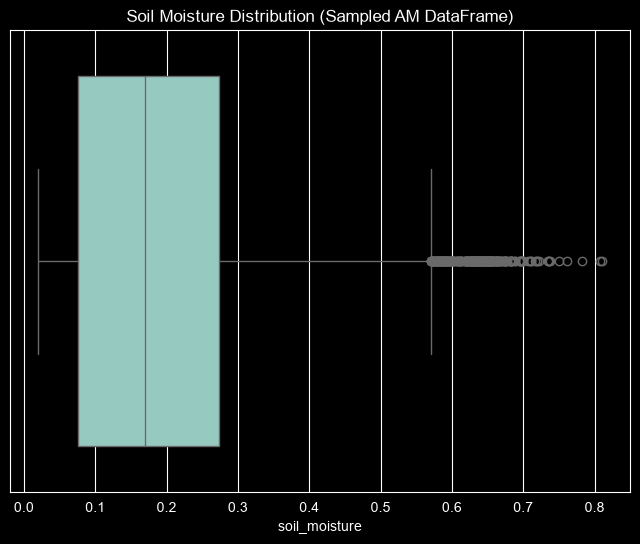

In [14]:
# Taking a random sample of 10,000 rows for plotting
df_sample = df_clean.sample(n=10000, random_state=42)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x=df_sample['soil_moisture'])
plt.title("Soil Moisture Distribution (Sampled AM DataFrame)")
plt.show()


### Boxplot Analysis – Soil Moisture

- Central values concentrated between ~0.98 and 2.98
- Outliers appear starting around 0.58 and scattered up to ~0.8
- These points lie below the lower whisker, marking unusually low soil moisture values

**Observation:**
Outliers represent rare cases of significantly lower soil moisture compared to the bulk of the dataset. They may correspond to dry regions or data anomalies. Their scattered distribution suggests variability rather than a single systematic error.


In [15]:
df_sample.describe()

,soil_moisture,latitude,longitude
count,10000.000000,10000.000000,10000.000000
mean,0.195871,31.934774,29.680573
std,0.146223,29.788183,83.941742
min,0.020000,-55.099731,-179.766602
25%,0.075786,14.301665,-45.513485
50%,0.170139,38.007710,37.110996
75%,0.273500,56.850266,97.235474
max,0.810105,80.375343,179.393158


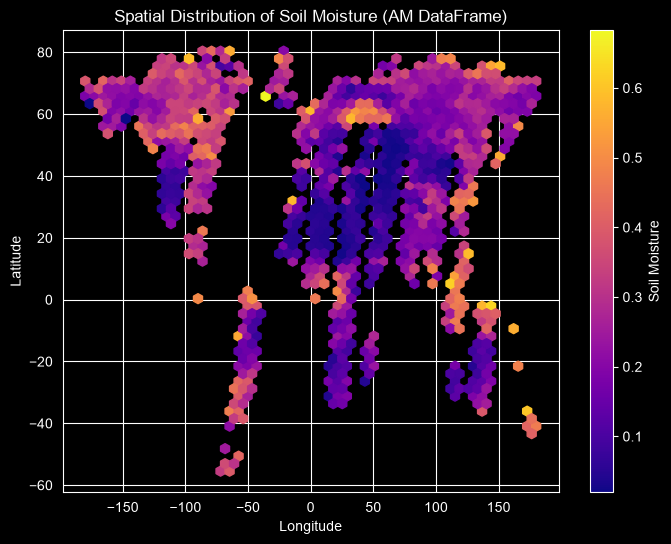

In [16]:
plt.figure(figsize=(8,6))
plt.hexbin(df_clean['longitude'], df_clean['latitude'],
           C=df_clean['soil_moisture'], gridsize=50, cmap='plasma')
plt.colorbar(label='Soil Moisture')
plt.title("Spatial Distribution of Soil Moisture (AM DataFrame)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Spatial Distribution – Soil Moisture (Hexbin with Plasma Colormap)

- Hexbin plot shows soil moisture variation across latitude and longitude
- Values range from ~0.1 (low, dry regions) to ~0.6 (high, wetter regions)
- Geographic patterns are visible: wetter climates show higher soil moisture, arid regions show lower values
- Outliers identified earlier (~0.58–0.8) correspond to specific spatial bins, not random noise
- Visualization uses the **Plasma colormap**, which highlights low values in dark purple and high values in bright yellow/orange

**Observation:**

Soil moisture shows clear global variation, with wetter zones in warm plasma colors and drier zones in cool tones. Outliers align with specific locations, suggesting real conditions or anomalies.



In [17]:
# Correlation matrix
df_clean.corr()


,soil_moisture,latitude,longitude
soil_moisture,1.000000,0.070204,-0.103597
latitude,0.070204,1.000000,-0.032831
longitude,-0.103597,-0.032831,1.000000


### Weak Correlations

- **Correlation** measures how two variables move together, ranging from **−1 to +1**.
  - **+1** : perfect positive correlation (both increase together).
  - **−1** : perfect negative correlation (one increases while the other decreases).
  - **0** : no linear relationship.

- **Weak Positive Correlation (~+0.07 between soil moisture & latitude)**
   As latitude increases, soil moisture shows a *slight upward tendency*.
   The value is close to 0, so the relationship is negligible.

- **Weak Negative Correlation (~−0.10 between soil moisture & longitude)**
   As longitude increases, soil moisture shows a *slight downward tendency*.
   Again, the effect is minimal.

- **Inference for Dataset**
   Soil moisture is **not strongly tied to latitude or longitude**.
   Local environmental factors (rainfall, vegetation, soil type) likely play a bigger role.


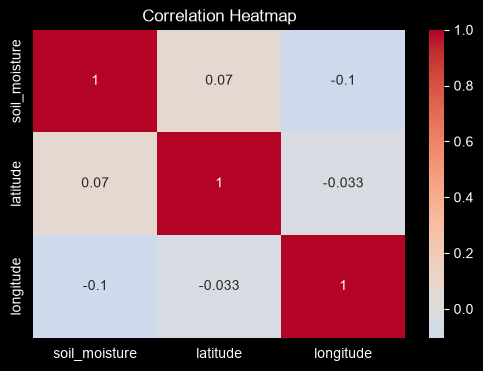

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


### Correlation Heatmap

**Observed Points:**
- Soil moisture vs latitude : weak positive (~0.07)
- Soil moisture vs longitude : weak negative (~−0.10)
- Latitude vs longitude : negligible (~−0.03)

**Conclusion**
Soil moisture shows **minimal dependence** on latitude/longitude.
-  Slight upward trend with latitude
-  Slight downward trend with longitude
-  Overall, geographic position alone does not explain soil moisture variation.



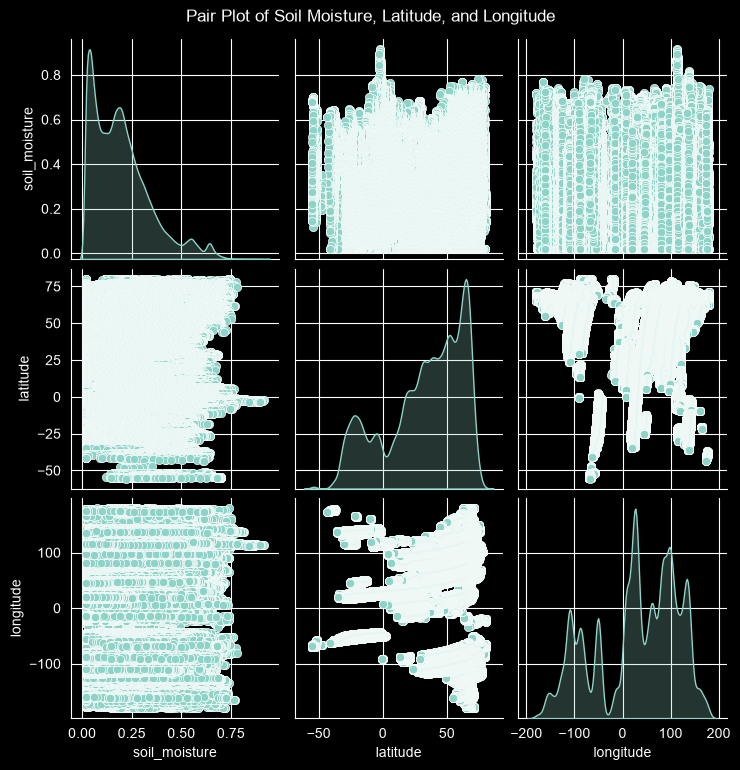

In [27]:
 # Pair plot for soil_moisture, latitude, and longitude
# diag_kind="kde"- shows Kernel Density Estimate on the diagonal
sns.pairplot(
    df_clean[['soil_moisture','latitude','longitude']],
    diag_kind="kde"
)

plt.suptitle("Pair Plot of Soil Moisture, Latitude, and Longitude", y=1.02)

plt.show()



### Pair Plot

**Observed Points:**
- Soil moisture KDE - values cluster in mid‑range, with few extreme outliers.
- Latitude KDE - data concentrated in certain latitude bands, not evenly spread.
- Longitude KDE - similar clustering, showing dense regions of sampling.

**Conclusion (Concise):**
KDE plots highlight **where values are most frequent**. Soil moisture is mid‑range concentrated, while latitude/longitude distributions show sampling clusters. This confirms that soil moisture variation is **not evenly distributed geographically**.


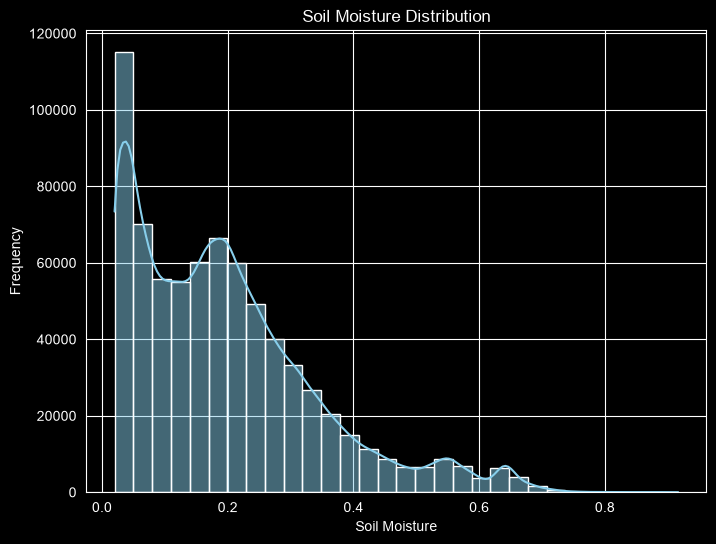

In [29]:
# Histogram + KDE for soil moisture

plt.figure(figsize=(8,6))
sns.histplot(
    df_clean['soil_moisture'],
    kde=True,          # adds smooth density curve
    bins=30,
    color="skyblue"
)

plt.title("Soil Moisture Distribution")
plt.xlabel("Soil Moisture")
plt.ylabel("Frequency")

plt.show()


### Soil Moisture Histogram + KDE

**Observed Points:**
- Most values are in the lower to mid range.
- The curve drops slowly toward the right side.
- A few very high values stretch the tail.

**Conclusion (Simple):**
Soil moisture is mostly moderate, but there are some rare cases of very high moisture.
- This makes the distribution **right‑skewed**.


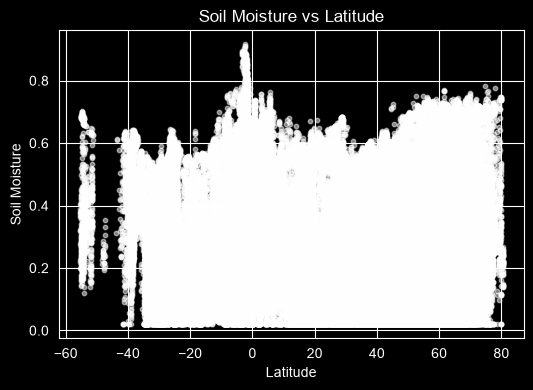

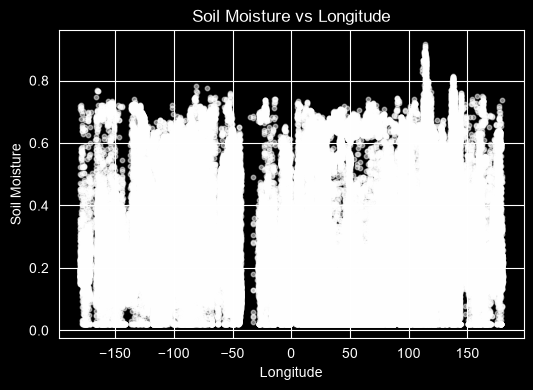

In [33]:
# Scatter plot: Soil Moisture vs Latitude

plt.figure(figsize=(6,4))
plt.scatter(
    df_clean['latitude'],
    df_clean['soil_moisture'],
    c='white', s=10, alpha=0.5
)
plt.title("Soil Moisture vs Latitude")
plt.xlabel("Latitude")
plt.ylabel("Soil Moisture")
plt.show()

# Scatter plot: Soil Moisture vs Longitude
plt.figure(figsize=(6,4))
plt.scatter(
    df_clean['longitude'],
    df_clean['soil_moisture'],
    c='white', s=10, alpha=0.5
)
plt.title("Soil Moisture vs Longitude")
plt.xlabel("Longitude")
plt.ylabel("Soil Moisture")
plt.show()



### Scatter Plots (Soil Moisture vs Latitude & Longitude)

**Observed Points:**
- Soil moisture vs latitude : points scattered with a slight upward slope (weak positive correlation ~0.07).
- Soil moisture vs longitude : points scattered with a slight downward slope (weak negative correlation ~−0.10).
- Overall spread : wide dispersion around both axes, no strong linear trend.

**Conclusion:**
Soil moisture shows **very weak dependence** on latitude and longitude.
- Slight increase with latitude
- Slight decrease with longitude
- Local environmental factors matter more than coordinates.


## Final Observations

- Soil moisture values are mostly moderate, with a few very high outliers.
- Distribution is right‑skewed - most readings cluster at lower/mid levels.
- Scatter plots show only weak links with latitude (slight increase) and longitude (slight decrease).
- Correlation heatmap confirms these weak relationships (~+0.07, ~−0.10).
- Pair plot highlights mid‑range soil moisture and uneven sampling across lat/long.

**Overall:**
Soil moisture variation is **not strongly explained by latitude or longitude**.
Local environmental factors (rainfall, soil type, vegetation) are more important drivers.
